In [188]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import h5py

import pandas as pd
import numpy as np
import scipy.stats as st
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
import sklearn.cluster as sc
from sklearn.semi_supervised import SelfTrainingClassifier 
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.model_selection import train_test_split

import os
# os.environ["OMP_NUM_THREADS"] = "9"


In [340]:

# Open the file in read-only mode
with h5py.File('stellar_circs.hdf5', 'r') as f:
    data = np.array(f['Snapshot_99']['MassTensorEigenVals'])
    names = np.array(f['Snapshot_99']['SubfindID'])

In [341]:
with h5py.File('aperture_masses.hdf5', 'r') as f:
    tot_aperture_masses = np.array(f['Snapshot_99']['SubhaloTotalMass_in_r100pkpc'])
    stellar_mass = np.array(f['Snapshot_99']['SubhaloStellarMass_in_r100pkpc'])
    id_ = np.array(f['Snapshot_99']['SubfindID'])

In [342]:
mass_mask = stellar_mass > 1e8
stellar_mass_masked = stellar_mass[mass_mask]
total_aperture_masses_masked = tot_aperture_masses[mass_mask]
ids_masses_masked   = id_[mass_mask]  

In [343]:
common_ids, idx_shapes, idx_masses = np.intersect1d(
    names, ids_masses_masked, return_indices=True
)

In [344]:
data   = data[idx_shapes]           # shape eigenvalues for matched subhalos
mass   = stellar_mass_masked[idx_masses]
tot_mass = total_aperture_masses_masked[idx_masses]  # M* for matched subhalos


In [190]:
flatness = data[:,0]/np.sqrt(data[:,1]*data[:,2])

(array([ 771., 1299., 1187.,  996.,  923.,  823.,  739.,  650.,  403.,
         113.]),
 array([0.10801911, 0.91191953, 1.71581995, 2.51972032, 3.3236208 ,
        4.12752151, 4.93142128, 5.735322  , 6.53922272, 7.34312248,
        8.1470232 ]),
 <BarContainer object of 10 artists>)

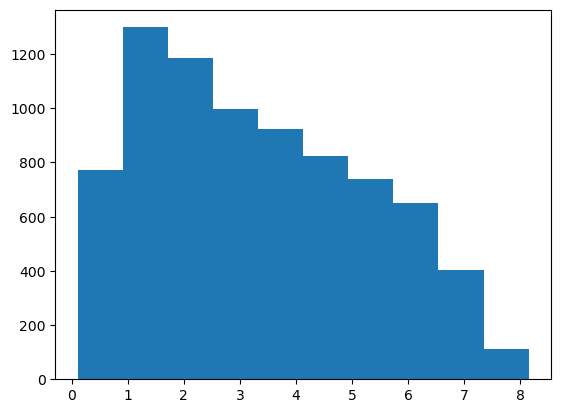

In [191]:
plt.hist(10*(1 - flatness))

In [192]:
data

array([[16.811005  , 20.398537  , 24.318338  ],
       [ 2.7137918 ,  4.8102655 ,  4.826274  ],
       [ 2.9132676 ,  4.2510724 ,  4.4541616 ],
       ...,
       [ 0.16548109,  0.23810346,  0.25309044],
       [ 0.84559387,  0.8559505 ,  0.8618702 ],
       [ 1.0614983 ,  1.12468   ,  1.1444045 ]],
      shape=(7904, 3), dtype=float32)

Text(0, 0.5, 'c/a')

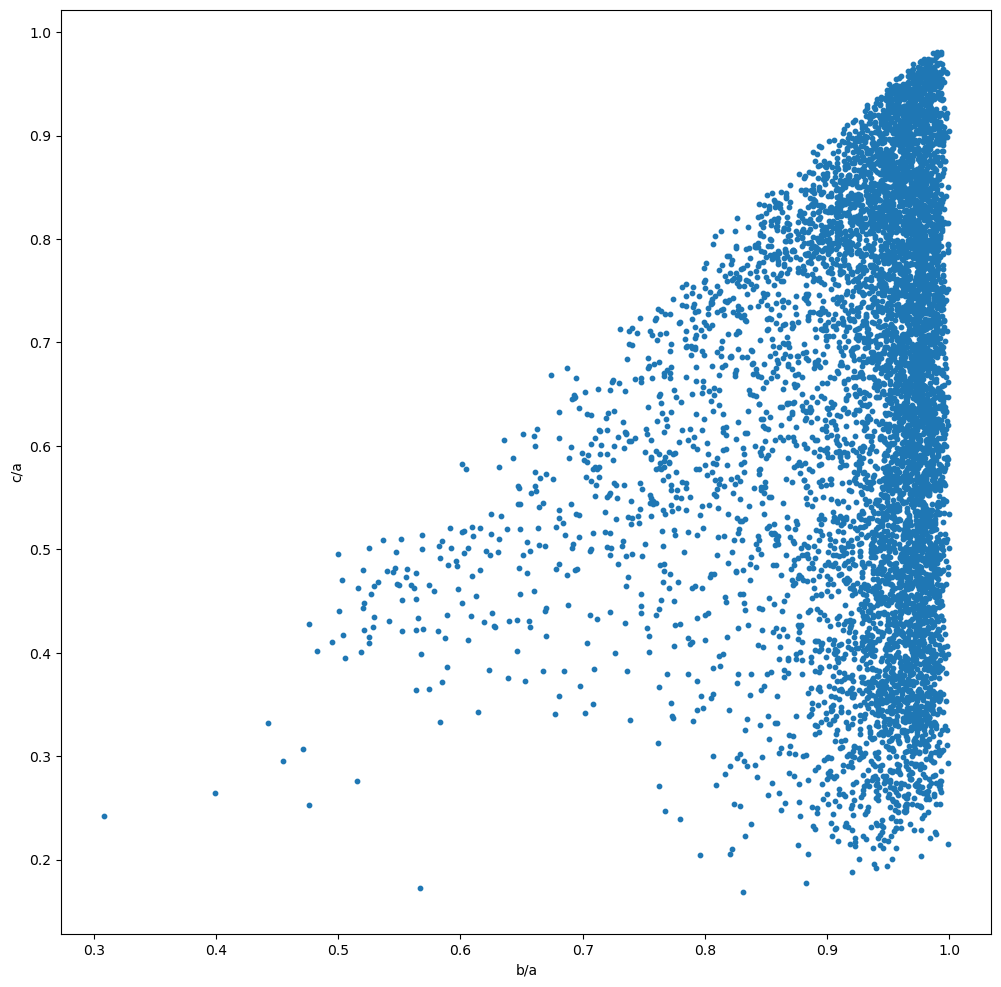

In [345]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()
    #projection='3d')

r10 = data[:, 0] / data[:, 2]
r20 = data[:, 1] / data[:, 2]
r21 = data[:, 0] / data[:, 1]

ax.scatter(r20, r10, s=10)
ax.set_xlabel('b/a')
ax.set_ylabel('c/a')
#ax.set_zlabel('r21')


## BIC calculation

In [194]:
def bic(X):
    bic_scores=[]
    models = dict()
    for k in range(1,10):
        gm=GaussianMixture(n_components=k).fit(X)
        bic_scores.append(gm.bic(X))
        models[k] = gm
    return bic_scores

In [195]:
b1=bic(data)

# b3=bic(log_data_RD)
bics = [b1]


In [196]:
def delta_bic(bic):
    delta_bic = []
    for k in range(1,9):
        delta_bic.append(bic[k-1]-bic[k])
    return delta_bic

delta_bics = [delta_bic(b) for b in bics]

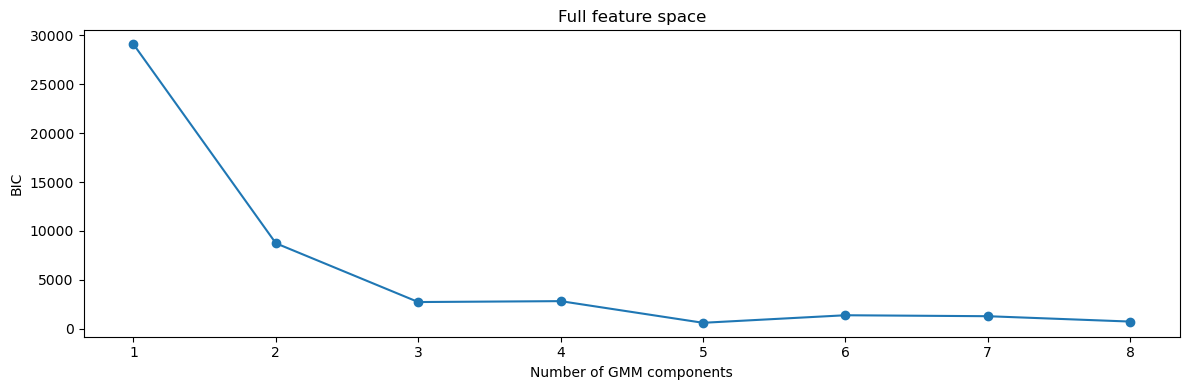

In [197]:
labels = ['Full feature space', 'Mass-Radius space', 'Density-Radius space']
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
for i, ax in enumerate([axes]):
    ax.plot(range(1,9), delta_bics[i], marker='o')
    ax.set_title(labels[i])
    ax.set_xlabel('Number of GMM components')
    ax.set_ylabel('BIC')

plt.tight_layout()
plt.savefig('bic_comparison.png')
plt.show()

In [300]:
ba = r10  # b/a
ca = r20  # c/a
T  = (1 - ba**2) / (1 - ca**2 + 1e-8)  # triaxiality

X = np.column_stack([ba, ca, T, mass])

In [346]:
masslog=np.log10(mass)
totmasslog=np.log10(tot_mass)

Text(0, 0.5, 'c/a')

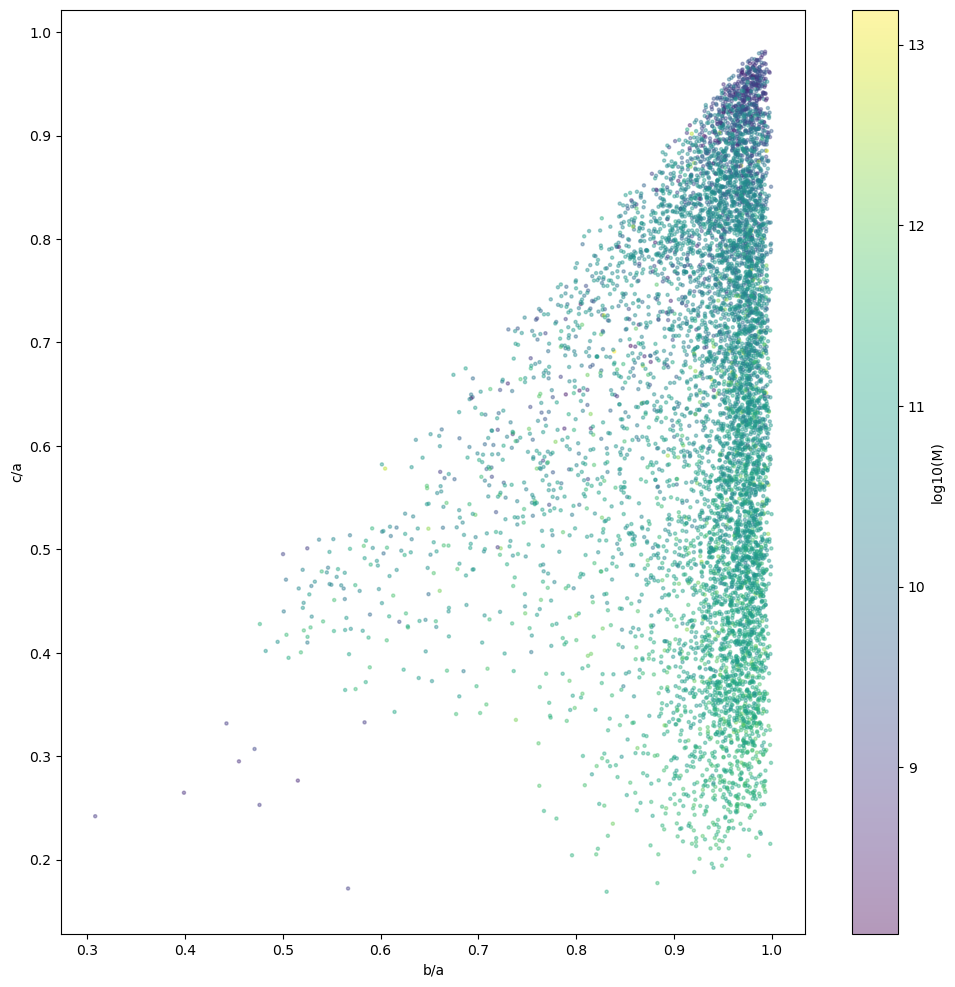

In [347]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()#projection='3d')
ax.scatter(r20, r10, c=totmasslog, alpha=0.4, s=5)
fig.colorbar(ax.collections[0], label='log10(M)')
ax.set_xlabel('b/a')
ax.set_ylabel('c/a')

Text(0, 0.5, 'c/a')

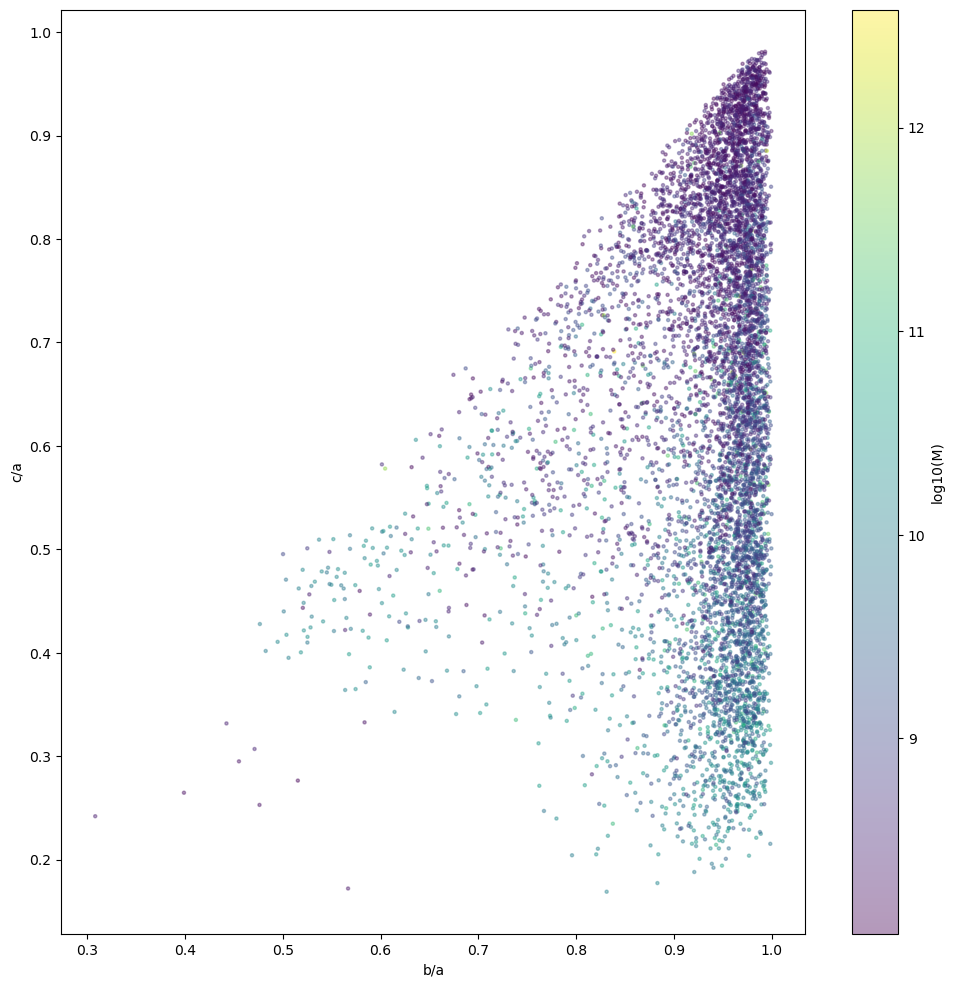

In [348]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()#projection='3d')
ax.scatter(r20, r10, c=masslog, alpha=0.4, s=5)
fig.colorbar(ax.collections[0], label='log10(M)')
ax.set_xlabel('b/a')
ax.set_ylabel('c/a')

In [201]:
hdb=sc.HDBSCAN(min_cluster_size=100).fit(X)

c:\Users\danic\miniconda3\envs\danicaenv2.0\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


c:\Users\danic\miniconda3\envs\danicaenv2.0\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


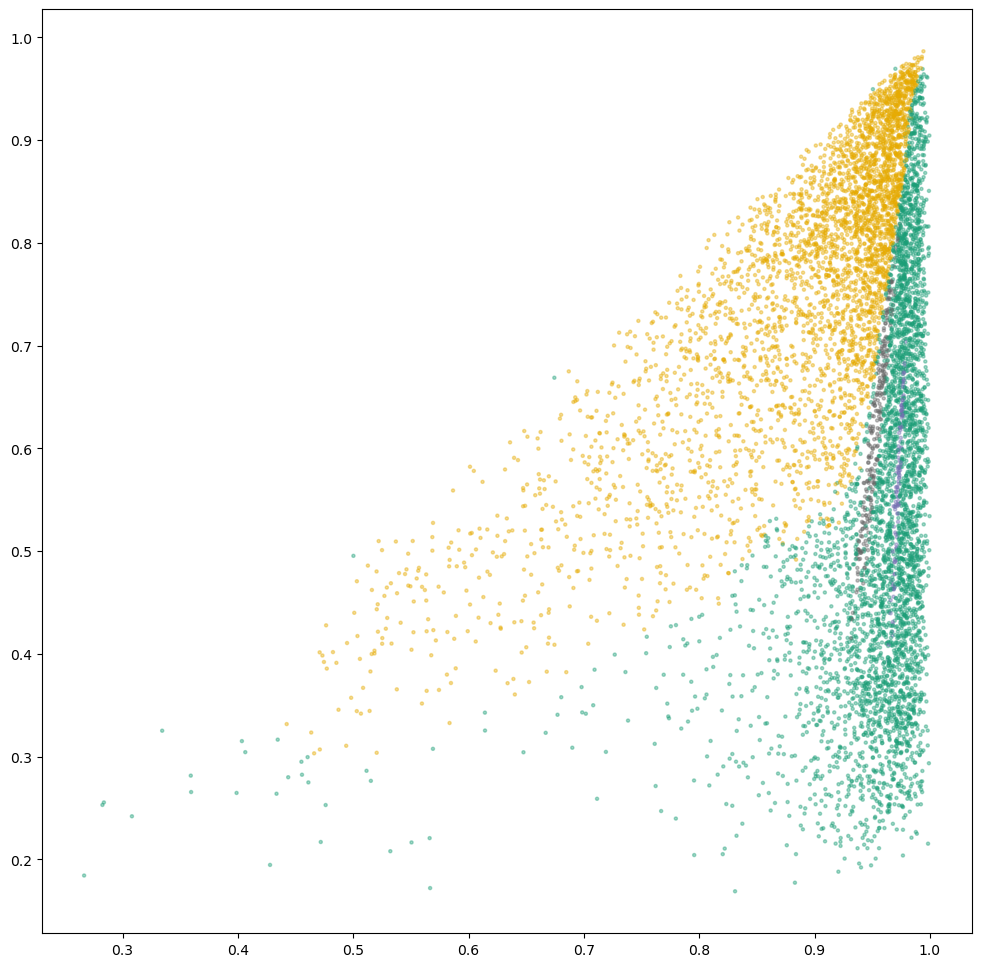

In [202]:
fig= plt.figure(figsize=(12, 12))
ax = fig.add_subplot()#projection='3d')
labels = hdb.fit_predict(X)
ax.scatter(r20, r10, c=labels, cmap='Dark2',s =5,alpha=0.4)



In [ ]:
tot_aperture_masses

(98342,)

c:\Users\danic\miniconda3\envs\danicaenv2.0\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


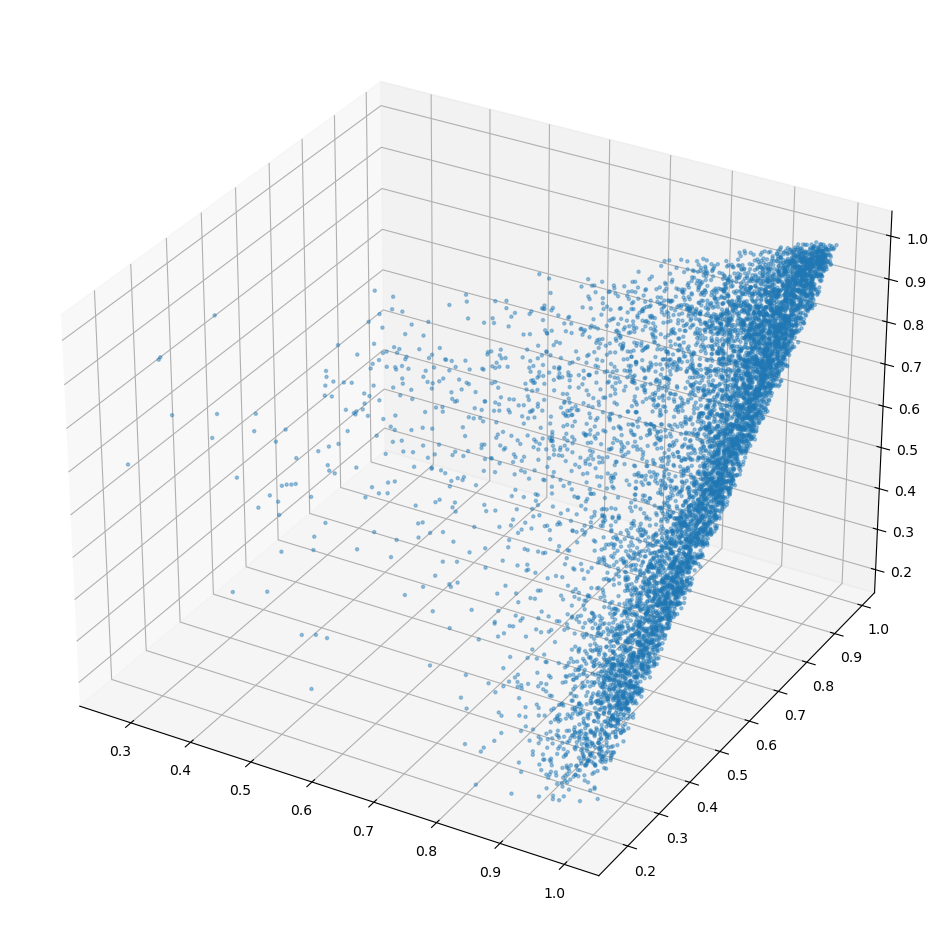

In [245]:
labels = sc.HDBSCAN(min_cluster_size=100).fit_predict(X)
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(projection='3d')
ax.scatter(r20, r10, r21,s =5,alpha=0.4)

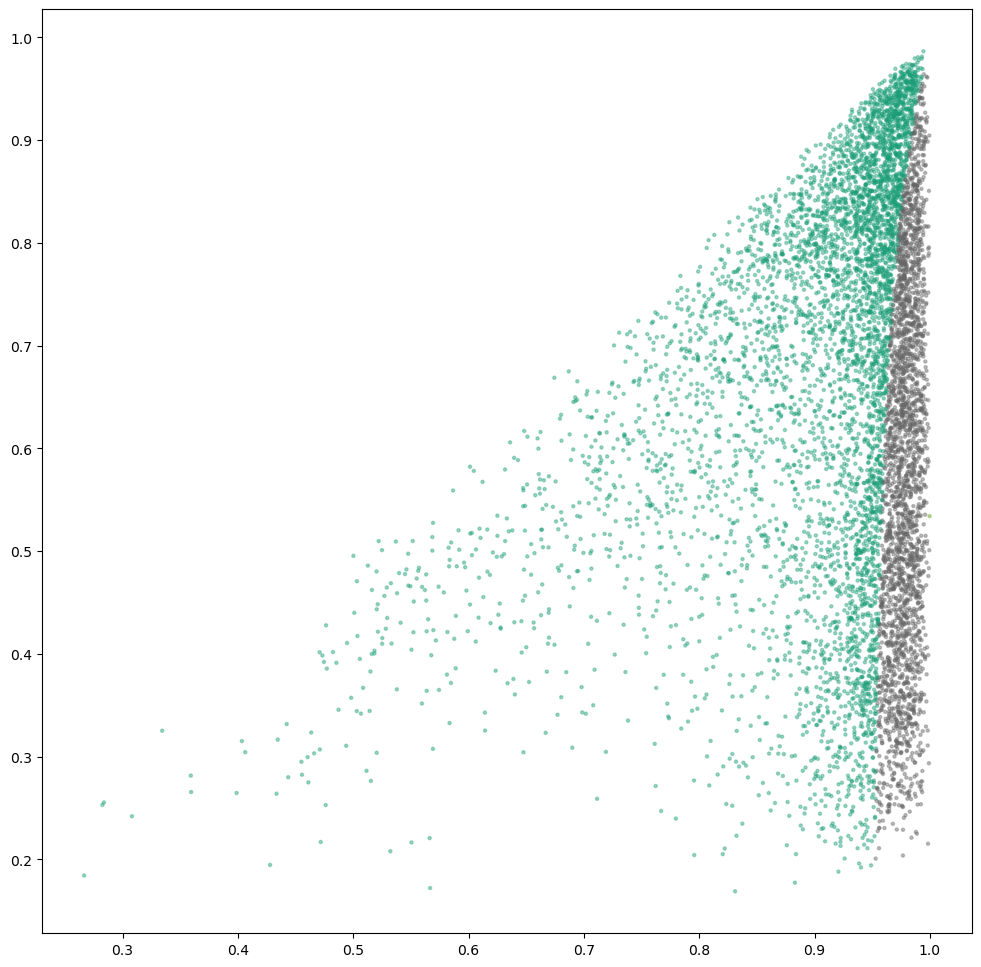

In [204]:
labelsgmm = GaussianMixture(n_components=3).fit_predict(X)
fig = plt.figure(figsize=(12, 12))  
ax = fig.add_subplot()#projection='3d')
ax.scatter(r20, r10, c=labelsgmm, cmap='Dark2',s =5,alpha=0.4)

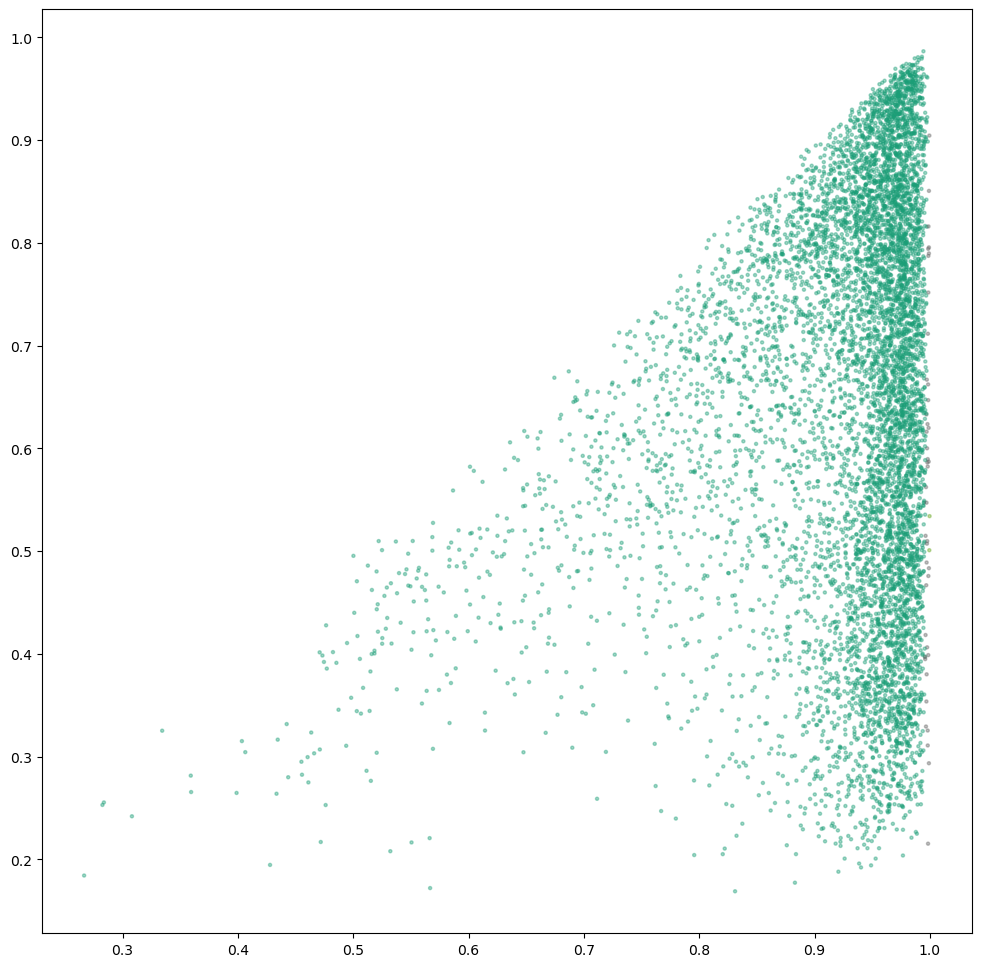

In [205]:
labelskmeans = sc.KMeans(n_clusters=3).fit_predict(X)

plt.figure(figsize=(12, 12))
ax = plt.subplot()
ax.scatter(r20, r10, c=labelskmeans, cmap='Dark2',s =5,alpha=0.4)

In [239]:


bgm = BayesianGaussianMixture(
    n_components=4,               # upper bound; model prunes unused ones
    covariance_type='full',       # allow arbitrary ellipsoidal clusters
    weight_concentration_prior_type='dirichlet_process',  # infinite mixture
    weight_concentration_prior=1e-2,  # low → aggressive pruning
    max_iter=500,
    n_init=5,
    random_state=42
)
bgm.fit(X)

# Inspect which components survived
print(np.round(bgm.weights_, 3))  # near-zero weights → pruned

labels = bgm.predict(X)
probs  = bgm.predict_proba(X)



[0.377 0.299 0.052 0.272]


Text(0, 0.5, 'b/a')

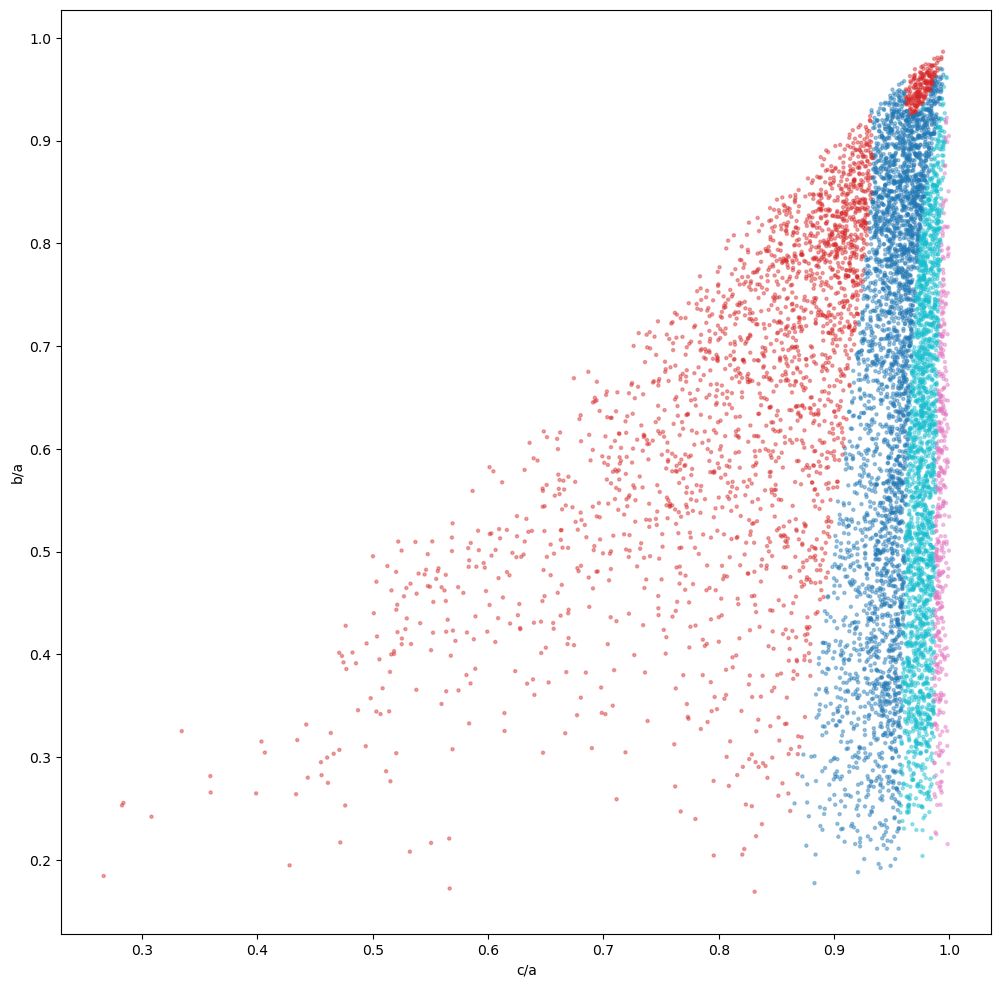

In [240]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()#projection='3d')     
ax.scatter(r20, r10, c=labels, cmap='tab10',s =5,alpha=0.4)
ax.set_xlabel('c/a')
ax.set_ylabel('b/a')

In [208]:
names.shape

(7904,)

In [226]:
# Get the indices of points which are mostly spherical (0.9 < r10 < 1.1 and 0.9 < r20 < 1.1)
s1 = np.argwhere((r10 > 0.9) & (r10 < 1.1))[:,  0]
s2 = np.argwhere((r20 > 0.9) & (r20 < 1.1))[:,  0]

s_arr = np.intersect1d(s1, s2)

# Get the indices of points which are oblate
o1 = np.argwhere(r10 < 1)[:, 0]
o2 = np.argwhere(r20 > 0.9)[:, 0]
o_arr = np.intersect1d(o1, o2)
o_arr = np.setdiff1d(o_arr, s_arr)

# Get the indices of points which are prolate
p_arr = np.argwhere((r10 + 0.1 >= r20) & (r10 - 0.1 <= r20))[:, 0]
p_arr = np.setdiff1d(p_arr, s_arr)
p_arr = np.setdiff1d(p_arr, o_arr)

t_arr = np.setdiff1d(np.arange(len(r10)), np.union1d(np.union1d(s_arr, o_arr), p_arr))

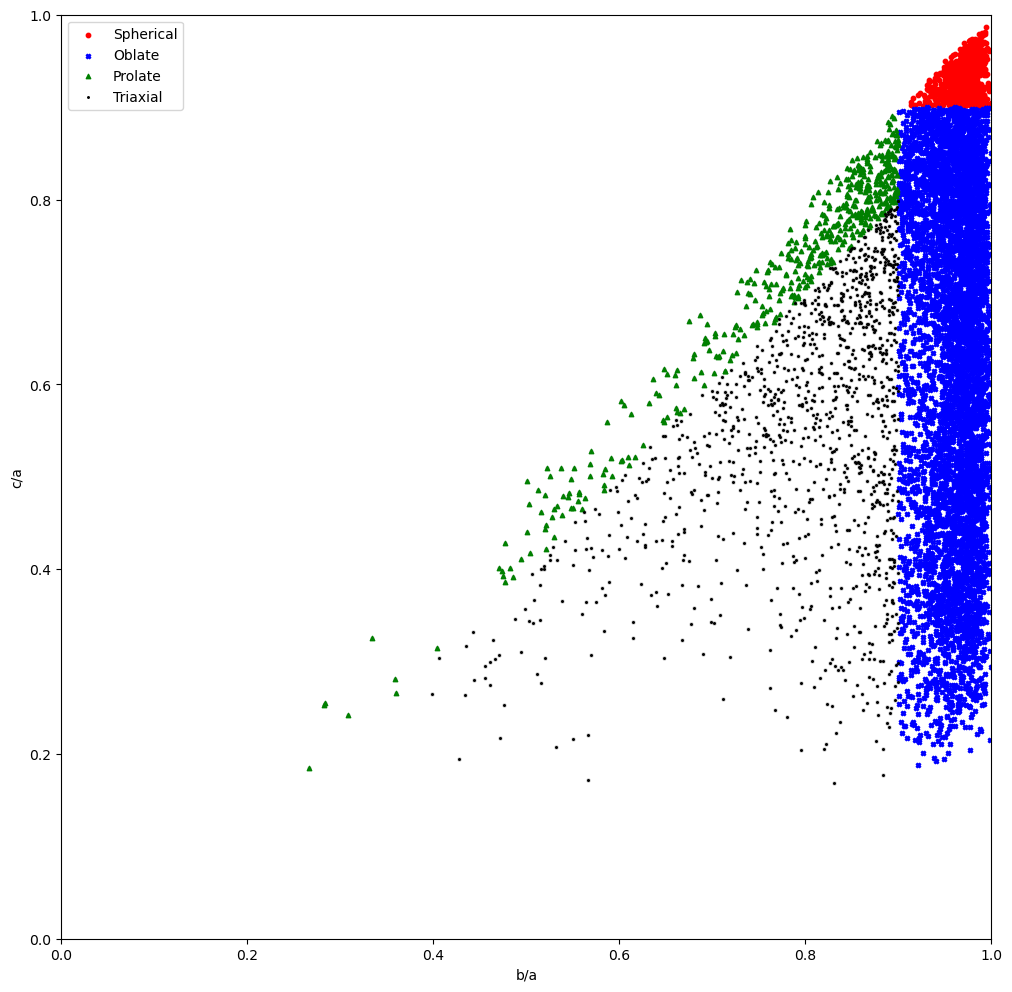

In [230]:
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot()#projection='3d')     
ax.scatter(r20, r10, color='gray', s=5, alpha=0.4)
ax.scatter(r20[s_arr], r10[s_arr], marker='o', c='red', s=10, label='Spherical')
ax.scatter(r20[o_arr], r10[o_arr], marker='X', c='blue', s=10, label='Oblate')
ax.scatter(r20[p_arr], r10[p_arr], marker='^', c='green', s=10, label='Prolate')    
ax.scatter(r20[t_arr], r10[t_arr], marker='.', c='black', s=5, label='Triaxial')
ax.set_xlabel('b/a')
ax.set_ylabel('c/a')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()